# Snake RL - Full Evaluation
This notebook downloads the trained weights for all agents (DQN, REINFORCE, Actor-Critic) from Google Drive and evaluates them against the Baseline.

In [2]:
%pip install gdown
import gdown
import os

file_id = '1K9SNjbA8DuX7W0P2voedvmopyhIh9dQx'
output = 'weights.zip'

if not os.path.exists('allWeigths'):
    print("Downloading weights from Google Drive...")
    gdown.download(id=file_id, output=output, quiet=False)
    os.makedirs('allWeigths', exist_ok=True)
    !unzip -o -j weights.zip -d allWeigths
    !rm weights.zip
else:
    print("allWeigths folder already exists. Skipping download.")

Downloading...
From: https://drive.google.com/uc?id=1K9SNjbA8DuX7W0P2voedvmopyhIh9dQx
To: /home/gian/Desktop/Reinforcement-Learning/snake/weights.zip
100%|██████████| 8.71M/8.71M [00:00<00:00, 10.5MB/s]


Archive:  weights.zip
  inflating: allWeigths/._allWeights  
  inflating: allWeigths/reinforce_partially_observable.h5  
  inflating: allWeigths/._reinforce_partially_observable.h5  
  inflating: allWeigths/dqn_partially_observable.h5  
  inflating: allWeigths/._dqn_partially_observable.h5  
  inflating: allWeigths/reinforce_fully_observable.h5  
  inflating: allWeigths/._reinforce_fully_observable.h5  
  inflating: allWeigths/actor_critic_partially_observable.h5  
  inflating: allWeigths/._actor_critic_partially_observable.h5  
  inflating: allWeigths/dqn_fully_observable_log.npz  
  inflating: allWeigths/._dqn_fully_observable_log.npz  
  inflating: allWeigths/actor_critic_partially_observable_log.npz  
  inflating: allWeigths/._actor_critic_partially_observable_log.npz  
  inflating: allWeigths/dqn_fully_observable.h5  
  inflating: allWeigths/._dqn_fully_observable.h5  
  inflating: allWeigths/actor_critic_fully_observable.h5  
  inflating: allWeigths/._actor_critic_fully_observabl

In [3]:
import sys
import numpy as np
import tensorflow as tf

from utils import set_all_seeds, get_valid_actions_mask_from_env
from environments_fully_observable import OriginalSnakeEnvironment as FullyObsEnv
from environments_partially_observable import OriginalSnakeEnvironment as PartiallyObsEnv
from baseline import run_baseline
from agents.dqn_agent import DQNAgent
from agents.reinforce_agent import REINFORCEAgent
from agents.actor_critic_agent import ActorCriticAgent

WEIGHTS_DIR = 'allWeigths'
import glob
print("Weights available:", glob.glob(f"{WEIGHTS_DIR}/*.h5"))

2026-03-16 10:21:37.516397: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 10:21:37.536673: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 10:21:37.536691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 10:21:37.537222: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 10:21:37.540556: I tensorflow/core/platform/cpu_feature_guar

Weights available: ['allWeigths/dqn_fully_observable.h5', 'allWeigths/reinforce_partially_observable.h5', 'allWeigths/dqn_partially_observable.h5', 'allWeigths/actor_critic_partially_observable.h5', 'allWeigths/actor_critic_fully_observable.h5', 'allWeigths/reinforce_fully_observable.h5']


In [4]:
def evaluate_agent(agent, env, n_steps):
    all_rewards = []
    fruits_eaten = 0
    wall_hits = 0
    self_hits = 0
    wins = 0
    
    for _ in range(n_steps):
        state = env.to_state()
        if hasattr(state, 'numpy'): state = state.numpy()
        mask = get_valid_actions_mask_from_env(env)
        actions = agent.select_action_greedy(state, mask)
        
        rewards = env.move(actions.reshape(-1, 1)).numpy().flatten()
        
        all_rewards.append(np.mean(rewards))
        fruits_eaten += np.sum(rewards == 0.5)
        wall_hits += np.sum(rewards == -0.1)
        self_hits += np.sum(rewards == -0.2)
        wins += np.sum(rewards == 1.0)
        
    return {
        'avg_reward': np.mean(all_rewards),
        'fruits_eaten': int(fruits_eaten),
        'wall_hits': int(wall_hits),
        'self_hits': int(self_hits),
        'wins': int(wins),
    }

def load_and_evaluate(algo, env_type):
    set_all_seeds(0)
    if env_type == 'fully_observable':
        env = FullyObsEnv(100, 7)
        C, H, W = 4, 7, 7
    else:
        env = PartiallyObsEnv(100, 7, 2)
        C, H, W = 4, 5, 5

    if algo == 'dqn':
        agent = DQNAgent(C, H, W, 4)
    elif algo == 'reinforce':
        agent = REINFORCEAgent(C, H, W, 4)
    elif algo == 'actor_critic':
        agent = ActorCriticAgent(C, H, W, 4)
        
    weight_path = os.path.join(WEIGHTS_DIR, f'{algo}_{env_type}.h5')
    if not os.path.exists(weight_path):
        print(f"WARNING: weights not found at {weight_path}")
        return None
        
    agent.load(weight_path, eval_mode=True)
    return evaluate_agent(agent, env, 1000)

def print_results(name, res):
    if res is None:
        print(f"  {name}: no weights found\n")
        return
    print(f"  {name}: avg_reward={res['avg_reward']:.4f}, "
          f"fruits={res['fruits_eaten']}, wall_hits={res['wall_hits']}, "
          f"self_hits={res['self_hits']}, wins={res['wins']}\n")

In [5]:
set_all_seeds(0)
algos = ['dqn', 'reinforce', 'actor_critic']

for env_type in ['fully_observable', 'partially_observable']:
    print(f"\n{'='*60}")
    print(f"  {env_type.upper().replace('_', ' ')}")
    print(f"{'='*60}")

    # Baseline
    set_all_seeds(0)
    if env_type == 'fully_observable':
        env = FullyObsEnv(100, 7)
        bl = run_baseline(env, 1000, verbose=False)
    else:
        env = PartiallyObsEnv(100, 7, 2)
        bl = run_baseline(env, 1000, verbose=False, partially_observable=True, mask_size=2)
    print_results('Baseline (BFS)', bl)
    
    # RL Agents
    for algo in algos:
        res = load_and_evaluate(algo, env_type)
        print_results(algo.upper(), res)


  FULLY OBSERVABLE


2026-03-16 10:21:47.270588: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-16 10:21:47.302226: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


  Baseline (BFS): avg_reward=0.1124, fruits=23484, wall_hits=0, self_hits=2516, wins=2

Model loaded from allWeigths/dqn_fully_observable.h5
  DQN: avg_reward=0.1368, fruits=29156, wall_hits=0, self_hits=4477, wins=2

Model loaded from allWeigths/reinforce_fully_observable.h5
  REINFORCE: avg_reward=0.1308, fruits=28774, wall_hits=0, self_hits=6514, wins=0

Model loaded from allWeigths/actor_critic_fully_observable.h5
  ACTOR_CRITIC: avg_reward=0.1307, fruits=28848, wall_hits=0, self_hits=6777, wins=0


  PARTIALLY OBSERVABLE
  Baseline (BFS): avg_reward=0.0878, fruits=18475, wall_hits=0, self_hits=2280, wins=1

Model loaded from allWeigths/dqn_partially_observable.h5
  DQN: avg_reward=0.1234, fruits=26419, wall_hits=0, self_hits=4346, wins=0

Model loaded from allWeigths/reinforce_partially_observable.h5
  REINFORCE: avg_reward=0.1173, fruits=25691, wall_hits=0, self_hits=5559, wins=0

Model loaded from allWeigths/actor_critic_partially_observable.h5
  ACTOR_CRITIC: avg_reward=0.1193,


Fully Observable Learning Curves:


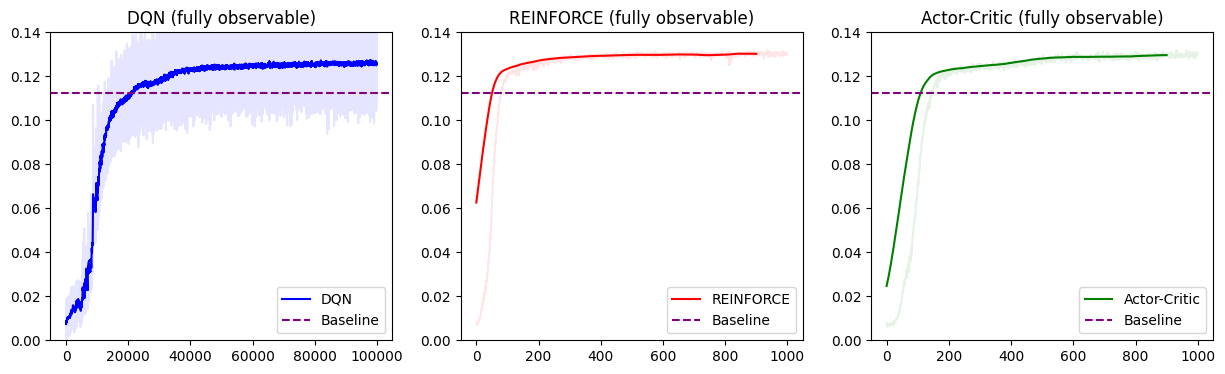


Partially Observable Learning Curves:


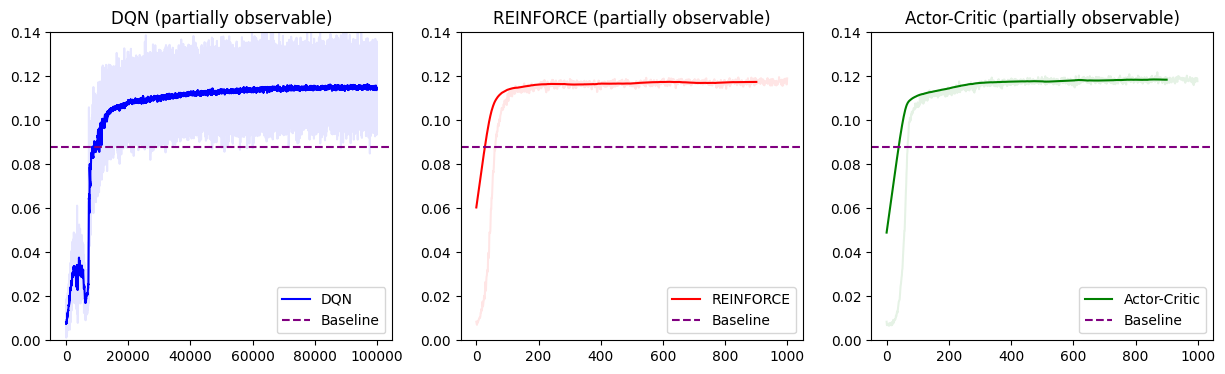

In [6]:
import matplotlib.pyplot as plt

def do_plots(type, bline):
    # Load logs
    d_log = np.load(f'{WEIGHTS_DIR}/dqn_{type}_log.npz', allow_pickle=True)['rewards']
    r_log = np.load(f'{WEIGHTS_DIR}/reinforce_{type}_log.npz', allow_pickle=True)['rewards']
    a_log = np.load(f'{WEIGHTS_DIR}/actor_critic_{type}_log.npz', allow_pickle=True)['rewards']

    # Smooth function
    w = 100
    d_sm = np.convolve(d_log, np.ones(w)/w, 'valid')
    r_sm = np.convolve(r_log, np.ones(w)/w, 'valid')
    a_sm = np.convolve(a_log, np.ones(w)/w, 'valid')

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    
    # dqn
    ax1.plot(d_sm, color='blue', label='DQN')
    ax1.plot(d_log, color='blue', alpha=0.1)
    ax1.axhline(y=bline, color='purple', linestyle='--', label='Baseline')
    ax1.set_ylim(0, 0.14)
    ax1.set_title(f"DQN ({type.replace('_', ' ')})")
    ax1.legend()
    
    # reinforce
    ax2.plot(r_sm, color='red', label='REINFORCE')
    ax2.plot(r_log, color='red', alpha=0.1)
    ax2.axhline(y=bline, color='purple', linestyle='--', label='Baseline')
    ax2.set_ylim(0, 0.14)
    ax2.set_title(f"REINFORCE ({type.replace('_', ' ')})")
    ax2.legend()
    
    # actor critic
    ax3.plot(a_sm, color='green', label='Actor-Critic')
    ax3.plot(a_log, color='green', alpha=0.1)
    ax3.axhline(y=bline, color='purple', linestyle='--', label='Baseline')
    ax3.set_ylim(0, 0.14)
    ax3.set_title(f"Actor-Critic ({type.replace('_', ' ')})")
    ax3.legend()

    plt.show()

# Generate plots for both environments
print('\nFully Observable Learning Curves:')
do_plots('fully_observable', 0.1124)

print('\nPartially Observable Learning Curves:')
do_plots('partially_observable', 0.0878)
